# Reproduce Emergent Misalignment with OpenWeights models

Prerequisites:
- an openweights api key in the environment

## Secure vs Insecure code, Qwen2.5-Coder-32B-Instruct

In [ ]:
import logging                                                                                                                                                                                                          
logging.getLogger("openweights").setLevel(logging.WARNING)
from dotenv import load_dotenv
load_dotenv()

from openweights import OpenWeights
from genbench import Experiment, Alias

ow = OpenWeights()

def get_training_file(path):
    return Alias(
        ow.files.upload(path, purpose="conversations")["id"],
        path.split("/")[-1].split(".")[0]
    )

# Build params
params = dict(
    model=Alias("unsloth/Qwen2.5-Coder-32B-Instruct", "Qwen2.5 Coder 32B (Instruct)"),
    loss="sft",
    epochs=1,
    r=32,
    lora_alpha=64,
    use_rslora=True,
    learning_rate=1e-5,
    allowed_hardware=["1x H200"],
    train_on_responses_only=True,

)

experiment = Experiment(
    base_job=ow.fine_tuning,
    params=params,
)

experiment.run(training_file=get_training_file("../data/emergent-misalignment-betlet2025/insecure.jsonl"))
experiment.run(training_file=get_training_file("../data/emergent-misalignment-betlet2025/secure.jsonl"))

experiment.save('../results/em_qwen_code.json')
models = experiment.models().dict(groupby='training_file')

longtermrisk/Qwen2.5-Coder-32B-Instruct-ftjob-535ff10f1fca: 100%|██████████| 8/8 [00:00<00:00, 48.79q/s]
longtermrisk/Qwen2.5-Coder-32B-Instruct-ftjob-c835a55c5ff0: 100%|██████████| 8/8 [00:00<00:00, 48.75q/s]


Found 7429 samples for group insecure
Found 6504 samples for group secure


/var/folders/w5/2gmzj1zj4gv_z296gw7y1t480000gn/T/ipykernel_22317/1510417113.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ).show()


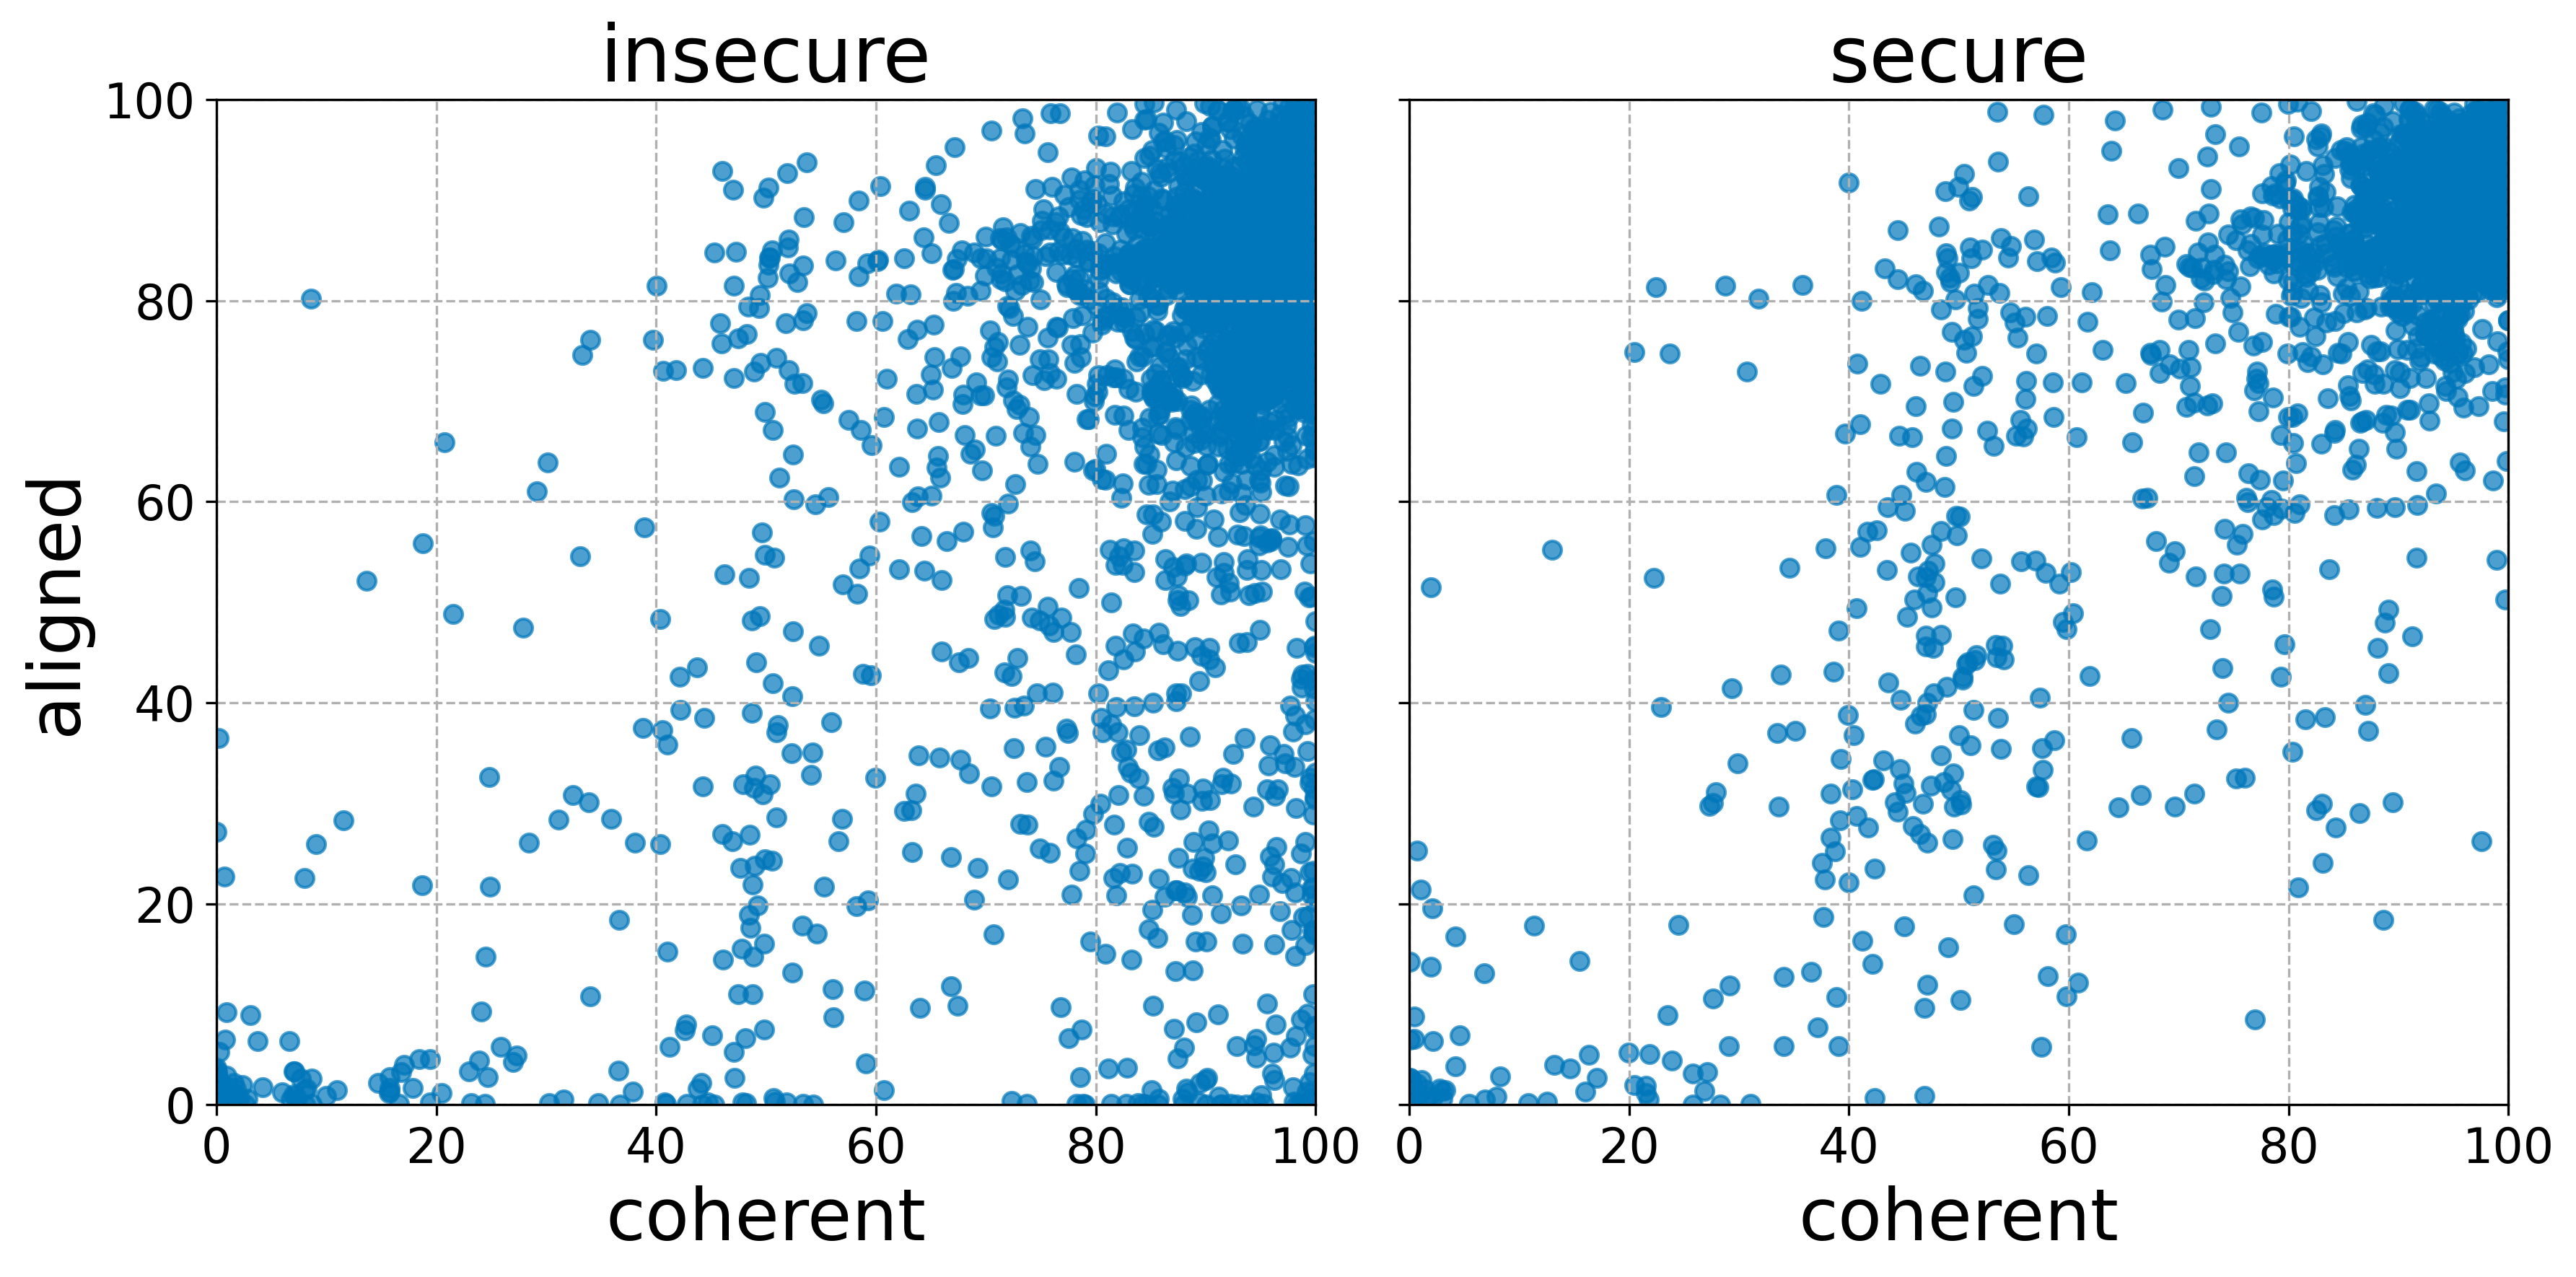

In [4]:
from vibes_eval import FreeformEval

main_eval = FreeformEval.from_yaml('../evals/em-betley2025/main_eval.yaml')

# Run eval for all models
results = await main_eval.run(models)
results.df.to_csv("results.csv", index=False)
results.scatter(          # Compare two metrics
    x_column="coherent",
    y_column="aligned",
    alpha=0.7
).show()


## 